In [4]:
import os
import glob
import pandas as pd

# ==============================================================================
# Step 1: Parse YOLO Annotation Files
# ==============================================================================

# Define the path to the labels folder. 
# Adjust the path based on where your notebook is located relative to the data folder.
labels_path = r'D:\RoadEye\data\processed\Roboflow_Ready\labels\*.txt'

# Initialize an empty list to store the extracted data
parsed_data = []

# Iterate through all text files in the specified directory
for file_path in glob.glob(labels_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
        
        for line in lines:
            # YOLO format: class_id x_center y_center width height
            parts = line.strip().split()
            
            # Ensure the line has exactly 5 elements to avoid index errors
            if len(parts) == 5:
                class_id = int(parts[0])
                x_center = float(parts[1])
                y_center = float(parts[2])
                width = float(parts[3])
                height = float(parts[4])
                
                # Append the extracted features as a dictionary
                parsed_data.append({
                    'filename': os.path.basename(file_path),
                    'class_id': class_id,
                    'x_center': x_center,
                    'y_center': y_center,
                    'width': width,
                    'height': height
                })

# Convert the list of dictionaries into a Pandas DataFrame for easier analysis
df = pd.DataFrame(parsed_data)

# Display the first 5 rows and the total number of bounding boxes
print("Data parsing complete!")
print(f"Total number of bounding boxes found: {len(df)}\n")
display(df.head())

Data parsing complete!
Total number of bounding boxes found: 6817



,filename,class_id,x_center,y_center,width,height
0,India_000005.txt,1,0.269444,0.728472,0.483333,0.143056
1,India_000011.txt,0,0.528472,0.722917,0.034722,0.162500
2,India_000014.txt,0,0.550694,0.847222,0.256944,0.225000
3,India_000014.txt,0,0.157639,0.856944,0.312500,0.252778
4,India_000017.txt,1,0.349306,0.897222,0.123611,0.088889


### 📌 Cell 1 Summary: Data Parsing & Initial Discovery

**What we did:**
We successfully parsed all YOLO-formatted annotation files (`.txt`) from our processed dataset and structured them into a readable Pandas DataFrame. 

**Key Findings:**
* **Total Objects:** We discovered a total of **6,817 bounding boxes** across our 3,223 images. 
* **Insight:** Since the number of bounding boxes (6,817) is significantly higher than the number of images (3,223), this confirms that many street images contain **multiple anomalies** (e.g., several cracks or potholes in the same frame).
* **Status:** The raw annotation data (Class ID, X-center, Y-center, Width, Height) is now properly formatted and ready for statistical analysis.

RoadEye Class Distribution:
------------------------------
class_name
Crack      3643
Pothole    3174
Name: count, dtype: int64
------------------------------


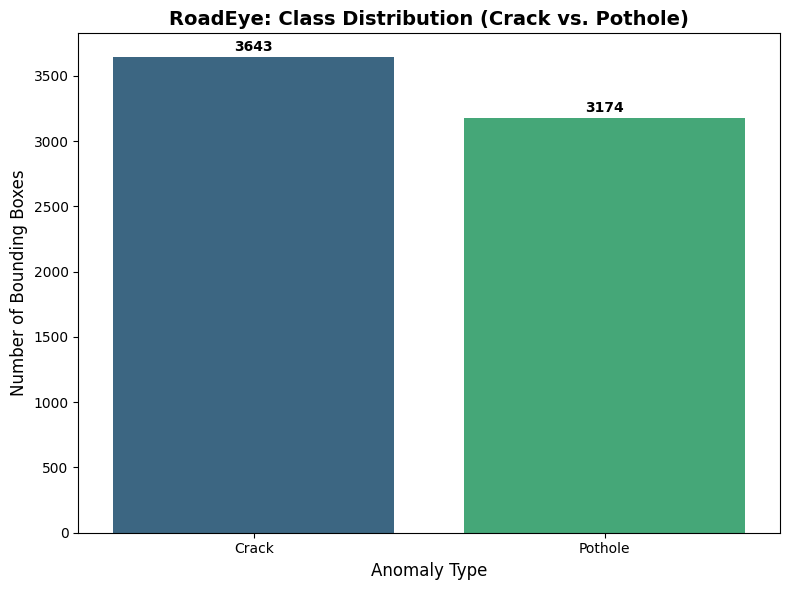

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# Step 2: Analyze Class Distribution (Imbalance Check)
# ==============================================================================

# Map class IDs to their actual names for better readability in the plot
# 0 -> Crack, 1 -> Pothole (based on our earlier preprocessing strategy)
class_mapping = {0: 'Crack', 1: 'Pothole'}
df['class_name'] = df['class_id'].map(class_mapping)

# Count the number of instances for each class
class_counts = df['class_name'].value_counts()

# Print the exact numerical counts
print("RoadEye Class Distribution:")
print("-" * 30)
print(class_counts)
print("-" * 30)

# Create a visual Bar Chart
plt.figure(figsize=(8, 6))
# Using seaborn for a cleaner, professional aesthetic
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, legend=False, palette='viridis')

# Add professional titles and labels
plt.title('RoadEye: Class Distribution (Crack vs. Pothole)', fontsize=14, fontweight='bold')
plt.xlabel('Anomaly Type', fontsize=12)
plt.ylabel('Number of Bounding Boxes', fontsize=12)

# Display the exact number on top of each bar for clarity
for index, value in enumerate(class_counts.values):
    plt.text(index, value + 50, str(value), ha='center', fontweight='bold')

# Render the plot
plt.tight_layout()
plt.show()

### 📌 Cell 2 Summary: Class Distribution & Balance Check

**What we did:**
We visualized the frequency of each class (Crack vs. Pothole) using a bar chart to identify any potential class imbalance in our training set.

**Key Findings:**
* **Cracks:** 3,643 instances (~53.4%)
* **Potholes:** 3,174 instances (~46.6%)
* **Insight:** The dataset is **highly balanced**. Unlike many real-world anomaly detection datasets, we do not suffer from severe class imbalance. 
* **Actionable Next Step:** We do not need to apply aggressive, class-specific oversampling techniques for Potholes during the Roboflow augmentation phase. Standard environmental augmentations (like brightness or noise adjustments) applied uniformly will be sufficient to improve model robustness.

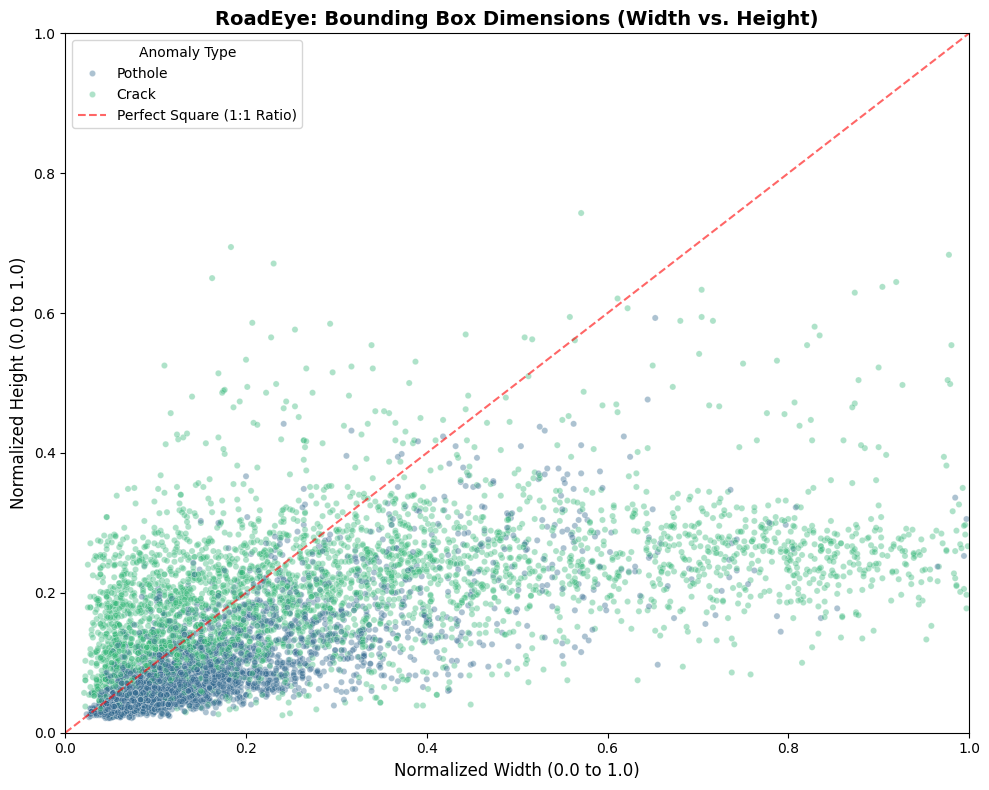

Average Bounding Box Area by Class:
-----------------------------------
class_name
Crack      7.595185
Pothole    2.298485
Name: box_area, dtype: float64
-----------------------------------


In [6]:
# ==============================================================================
# Step 3: Analyze Bounding Box Dimensions and Aspect Ratios
# ==============================================================================

# Calculate the relative area of each bounding box (width * height)
df['box_area'] = df['width'] * df['height']

# Create a Scatter Plot to visualize Width vs. Height
plt.figure(figsize=(10, 8))

# Using a scatter plot with transparency (alpha) to see overlapping points
sns.scatterplot(
    data=df, 
    x='width', 
    y='height', 
    hue='class_name', 
    palette='viridis', 
    alpha=0.4, 
    s=20  # marker size
)

# Draw a red dashed diagonal line representing a perfect square (1:1 aspect ratio)
# Anything above the line is taller than it is wide. Anything below is wider than it is tall.
plt.plot([0, 1], [0, 1], 'r--', alpha=0.6, label='Perfect Square (1:1 Ratio)')

# Professional formatting
plt.title('RoadEye: Bounding Box Dimensions (Width vs. Height)', fontsize=14, fontweight='bold')
plt.xlabel('Normalized Width (0.0 to 1.0)', fontsize=12)
plt.ylabel('Normalized Height (0.0 to 1.0)', fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(title='Anomaly Type')

plt.tight_layout()
plt.show()

# Print some quick statistical summaries about the areas
print("Average Bounding Box Area by Class:")
print("-" * 35)
print(df.groupby('class_name')['box_area'].mean() * 100) # Multiplied by 100 to show percentage
print("-" * 35)

### 📌 Cell 3 Summary: Bounding Box Dimensions & Aspect Ratio

**What we did:**
We analyzed the normalized width and height of all bounding boxes to understand the physical characteristics (size and shape) of the anomalies. We visualized this using a Scatter Plot and calculated the average relative area for each class.

**Key Findings:**
* **Size Alert (Small Objects):** The bounding boxes are generally very small relative to the image size. On average, Potholes occupy only **~2.3%** of the image area, while Cracks occupy **~7.6%**.
* **Shape Distribution:** * **Cracks** show high variance in aspect ratio (stretching horizontally and vertically), aligning with the nature of long road cracks.
  * **Potholes** are tightly clustered with smaller dimensions, often closer to a 1:1 aspect ratio (circular/square).
* **Actionable Next Step:** The small area of potholes indicates a "Small Object Detection" challenge. During preprocessing/augmentation on Roboflow, we must avoid scaling down images. Instead, using techniques like **Random Cropping** might help the model learn finer details of small potholes.

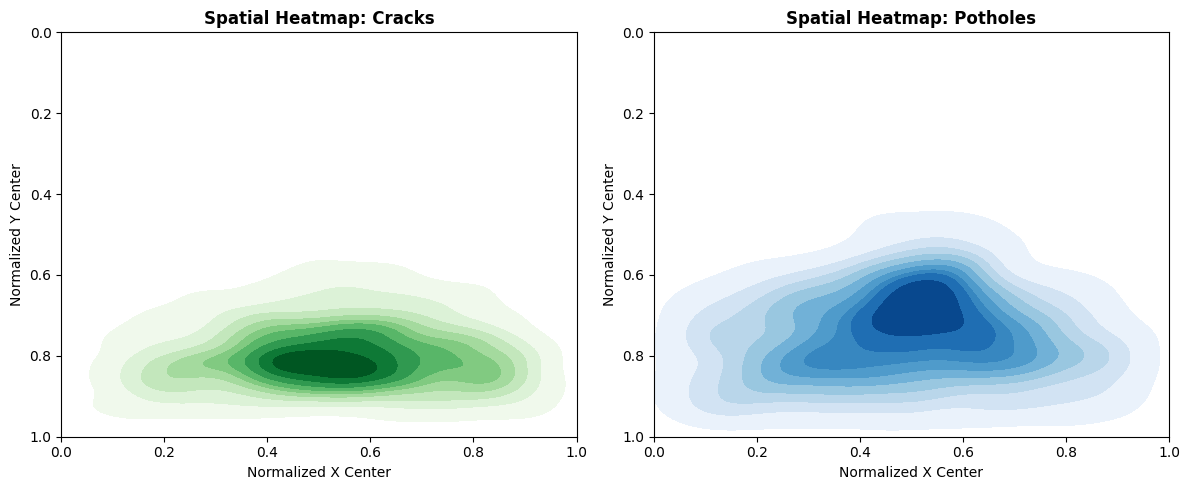

In [7]:
# ==============================================================================
# Step 4: Spatial Distribution (Heatmap of Anomaly Locations)
# ==============================================================================

plt.figure(figsize=(12, 5))

# Subplot 1: Heatmap for Cracks
plt.subplot(1, 2, 1)
sns.kdeplot(
    data=df[df['class_name'] == 'Crack'], 
    x='x_center', 
    y='y_center', 
    cmap='Greens', 
    fill=True, 
    thresh=0.05
)
plt.title('Spatial Heatmap: Cracks', fontsize=12, fontweight='bold')
plt.xlabel('Normalized X Center')
plt.ylabel('Normalized Y Center')
plt.xlim(0, 1)
plt.ylim(1, 0) # Inverted Y-axis to match image coordinates (top is 0)

# Subplot 2: Heatmap for Potholes
plt.subplot(1, 2, 2)
sns.kdeplot(
    data=df[df['class_name'] == 'Pothole'], 
    x='x_center', 
    y='y_center', 
    cmap='Blues', 
    fill=True, 
    thresh=0.05
)
plt.title('Spatial Heatmap: Potholes', fontsize=12, fontweight='bold')
plt.xlabel('Normalized X Center')
plt.ylabel('Normalized Y Center')
plt.xlim(0, 1)
plt.ylim(1, 0) # Inverted Y-axis to match image coordinates

plt.tight_layout()
plt.show()

### 📌 Cell 4 Summary: Spatial Distribution (Heatmap)

**What we did:**
We visualized the (X, Y) center coordinates of all bounding boxes to understand the typical locations of anomalies within the camera frame.

**Key Findings:**
* **Strict Lower-Half Bias:** Nearly 100% of the bounding boxes for both Cracks and Potholes are concentrated in the lower half of the images (Normalized Y-center > 0.5). The upper half (0.0 to 0.5) is completely empty.
* **Physical Context:** This strictly aligns with the nature of street-level photography (dashcams). The upper portion of the frame captures the horizon/sky, while the anomalies naturally exist on the road surface below.
* **Actionable Next Step:** The model will naturally learn this spatial prior (anomalies appear on the ground). During Roboflow augmentation, we must strictly avoid drastic vertical shifts. Translating anomalies into the upper half of the frame would create unrealistic training scenarios and confuse the model.